<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
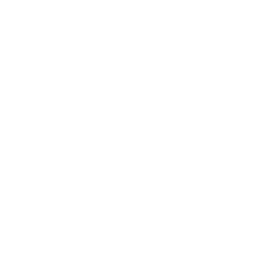
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Plan en parcelles divisées pour l'optimisation des procédés</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Fabrication / Ingénierie qualité &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Résumé exécutif

Ce notebook analyse une expérience en parcelles divisées (split-plot) pour un procédé de moulage par injection. Le facteur de grande parcelle est la **machine** (4 niveaux : MACH_A-MACH_D), difficile à modifier, et le facteur de sous-parcelle est le **réglage de vitesse** (5 niveaux : 60, 80, 100, 120, 140 tr/min), facile à modifier. Cinq mesures répétées sont prises pour chaque combinaison machine x vitesse, ce qui donne 100 observations du taux de défauts.

`PROC MIXED` ajuste correctement la structure de randomisation restreinte en traitant la **machine comme un effet aléatoire** (la strate d'erreur de grande parcelle) et la **vitesse comme un effet fixe** (le facteur de sous-parcelle). L'analyse estime les deux composantes de variance, teste l'effet de la vitesse et produit des comparaisons deux à deux ajustées par Tukey des moyennes des moindres carrés de vitesse afin d'identifier la vitesse de fonctionnement qui minimise le taux de défauts.

## Sources des données

| Source | Description | Enregistrements |
|--------|-------------|--------|
| WORK.MOLDING_EXPERIMENT | Données expérimentales en parcelles divisées : 4 machines x 5 vitesses x 5 répétitions | 100 |

---

In [1]:
/* --------------------------------------------------------
   Generer des donnees synthetiques en parcelles divisees
   pour un procede de moulage par injection
   4 machines (grande parcelle) x 5 vitesses (sous-parcelle)
   x 5 repetitions
   -------------------------------------------------------- */
DONNÉES work.molding_experiment;
    APPELER streaminit(42);
    TABLEAU machine_names[4] $12 _temporary_ ('MACH_A' 'MACH_B' 'MACH_C' 'MACH_D');
    TABLEAU speed_settings[5] _temporary_ (60 80 100 120 140);
    /* Effets machine reels (aleatoires) */
    TABLEAU mach_eff[4] _temporary_ (2.1 -1.5 0.8 -1.4);
    /* Effets vitesse reels (fixes, quadratiques, optimum ~100) */
    TABLEAU speed_eff[5] _temporary_ (3.2 1.0 -0.5 0.8 4.5);
    obs_id = 0;
    FAIRE whole_plot = 1 JUSQU_À 5;
        FAIRE m = 1 JUSQU_À 4;
            machine = machine_names[m];
            machine_id = cat('WP_', put(whole_plot, z2.), '_', machine);
            /* Effet de repetition de grande parcelle */
            wp_noise = rand('normal', 0, 1.5);
            FAIRE s = 1 JUSQU_À 5;
                speed = speed_settings[s];
                speed_label = cat(put(speed, 3.), 'RPM');
                /* Repetitions de sous-parcelle au sein de chaque grande parcelle */
                FAIRE rep = 1 JUSQU_À 5;
                    obs_id + 1;
                    /* Taux de defauts : intercept + machine + vitesse + interaction + bruit */
                    defect_rate = round(
                        8.0 + mach_eff[m] + speed_eff[s] +
                        wp_noise +
                        0.3 * (m - 2) * (s - 3) +
                        rand('normal', 0, 1.2),
                    0.01);
                    SI defect_rate < 0 ALORS defect_rate = 0.01;
                    /* Reponse secondaire : resistance a la traction */
                    tensile_strength = round(
                        45 - 0.5 * defect_rate +
                        rand('normal', 0, 2),
                    0.1);
                    SORTIE;
                FIN;
            FIN;
        FIN;
    FIN;
    SUPPRIMER m s mach_eff1-mach_eff4 speed_eff1-speed_eff5 wp_noise;
EXÉCUTER;


NOTE: DATA work.molding_experiment

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.molding_experiment (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.05 seconds
  cpu   0.05 seconds


---

In [2]:
/* --------------------------------------------------------
   Reference : synthese du taux de defauts par machine et vitesse
   -------------------------------------------------------- */
PROC MEANS data=work.molding_experiment n mean std;
    CLASSE machine speed_label;
    VAR defect_rate tensile_strength;
    ÉTIQUETTE machine="Machine"
          speed_label="Vitesse"
          defect_rate="Taux de défauts (%)"
          tensile_strength="Résistance à la traction";
    TITRE "Taux de défauts et résistance à la traction par machine et vitesse";
EXÉCUTER;

                           Taux de défauts et résistance à la traction par machine et vitesse                           

                                                  The MEANS Procedure

                                  Analysis Variable : defect_rate Taux de défauts (%)

        Machine   Vitesse           N Obs           Mean        Std Dev
        ---------------------------------------------------------------
        MACH_A     60RPM                5     12.9460000      1.0100149
        MACH_A     80RPM                5     10.0160000      0.6740401
        MACH_A    100RPM                5      7.5980000      0.9787083
        MACH_A    120RPM                5     10.2660000      0.9490416
        MACH_A    140RPM                5     13.7120000      0.9359594
        MACH_B     60RPM                5     11.7420000      0.9476656
        MACH_B     80RPM                5      8.5580000      1.0129018
        MACH_B    100RPM                5      6.5840000      0.8041952



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                           Taux de défauts et résistance à la traction par machine et vitesse                           




NOTE: PROC MEANS
NOTE: Output dataset work.cell_means has 30 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.cell_means

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


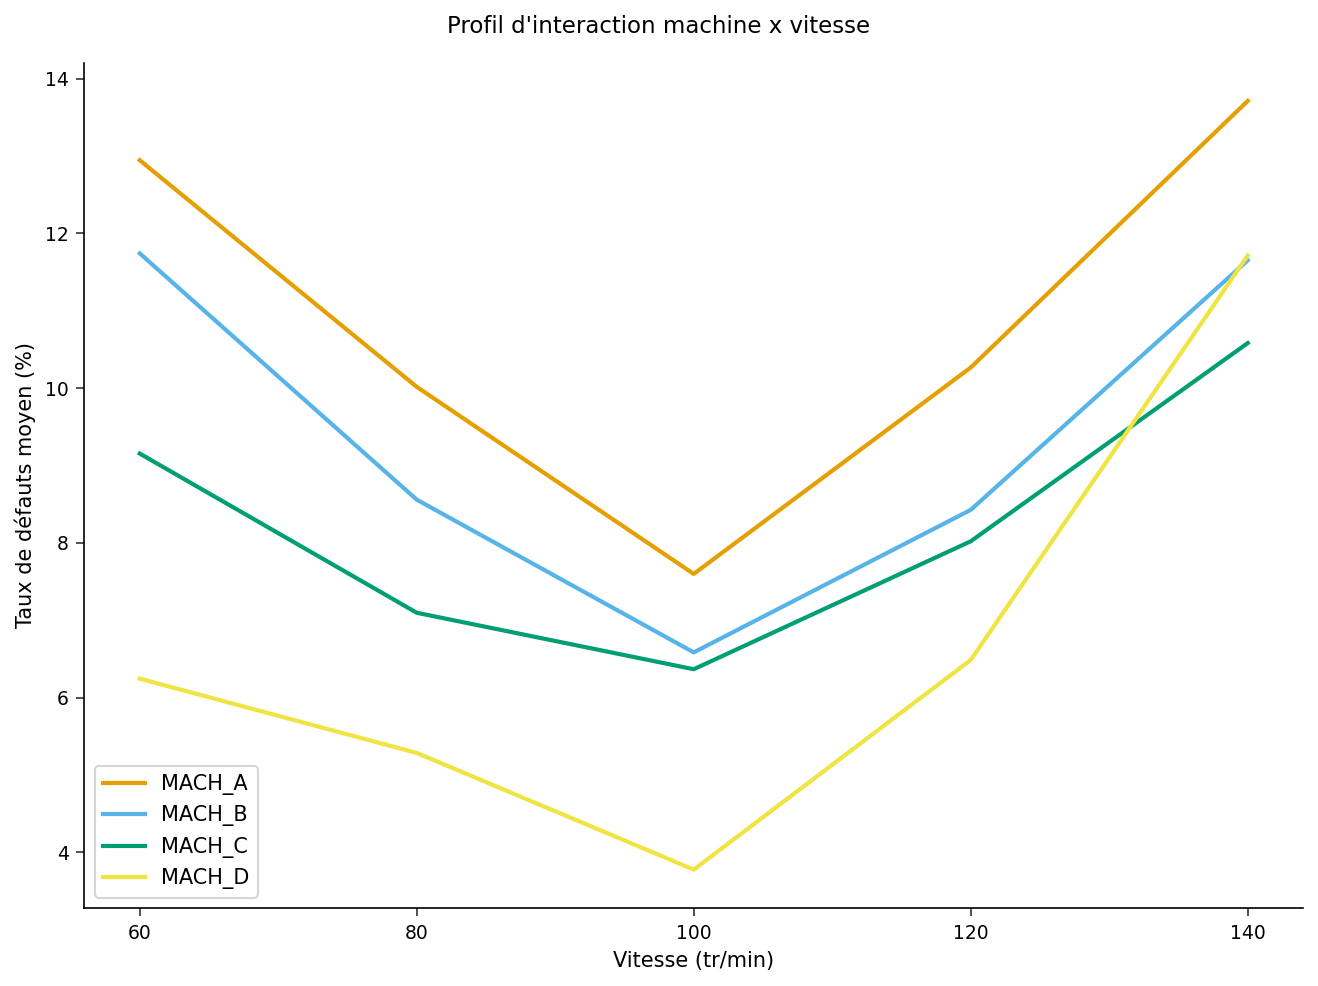

In [3]:
/* --------------------------------------------------------
   Graphique d'interaction : taux de defauts moyen par vitesse et machine
   -------------------------------------------------------- */
PROC MEANS data=work.molding_experiment SANS_IMPRESSION;
    CLASSE machine speed;
    VAR defect_rate;
    SORTIE out=work.cell_means mean=mean_defect;
EXÉCUTER;

PROC SGPLOT data=work.cell_means(OÙ=(_type_=3));
    SERIES x=speed y=mean_defect / GROUPE=machine
        LINEATTRS=(thickness=2) MARKERS;
    XAXIS ÉTIQUETTE="Vitesse (tr/min)" VALUES=(60 80 100 120 140);
    YAXIS ÉTIQUETTE="Taux de défauts moyen (%)";
    TITRE "Profil d'interaction machine x vitesse";
EXÉCUTER;

---

                           Taux de défauts et résistance à la traction par machine et vitesse                           

              The Mixed Procedure              
               Model Information               

Item                                      Value
-------------------------  --------------------
Dependent Variable          Taux de défauts (%)
Estimation Method                          REML
Degrees of Freedom Method         Kenward-Roger
Number of Observations                      100

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  machine     3.1033
Residual               1.6566

        Type III Tests of Fixed Effects         

Effect      Num DF    Den DF   F Value    Pr > F
--------  --------  --------  --------  --------
Vitesse          4      92.0     60.26    <.0001

         Fit Statistics          

Statistic                   Value
-----------------------  --------
-2 Res Log Likelihood    347.3514
AIC 


NOTE: PROC MIXED data=work.molding_experiment

NOTE: PROC MIXED: using R wrapper (mixed_renderer.R).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: lmer formula: defect_rate ~ speed_label + (1 | machine)
NOTE: Warning message:
NOTE: In readLines(con = "stdin") : incomplete final line found on 'stdin'
NOTE: ODS plot written: mixed_residuals_vs_predicted.spec.json
NOTE: ODS plot written: mixed_residual_histogram_panel.spec.json
NOTE: ODS plot written: mixed_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: mixed_qq_plot.spec.json
NOTE: ODS plot written: mixed_diagnostics.spec.json
NOTE: PROC MIXED ODS Graphics generated.
NOTE: ODS OUTPUT: SolutionF written to 'split_fixed'.
NOTE: ODS OUTPUT: CovParms written to 'split_covparms'.
NOTE: ODS OUTPUT: LSMeans written to 'speed_lsmeans'.
NOTE: ODS OUTPUT: FitStatistics written to 'split_fit'.
NOTE: ODS OUTPUT: Diffs written to 'speed_diffs'.


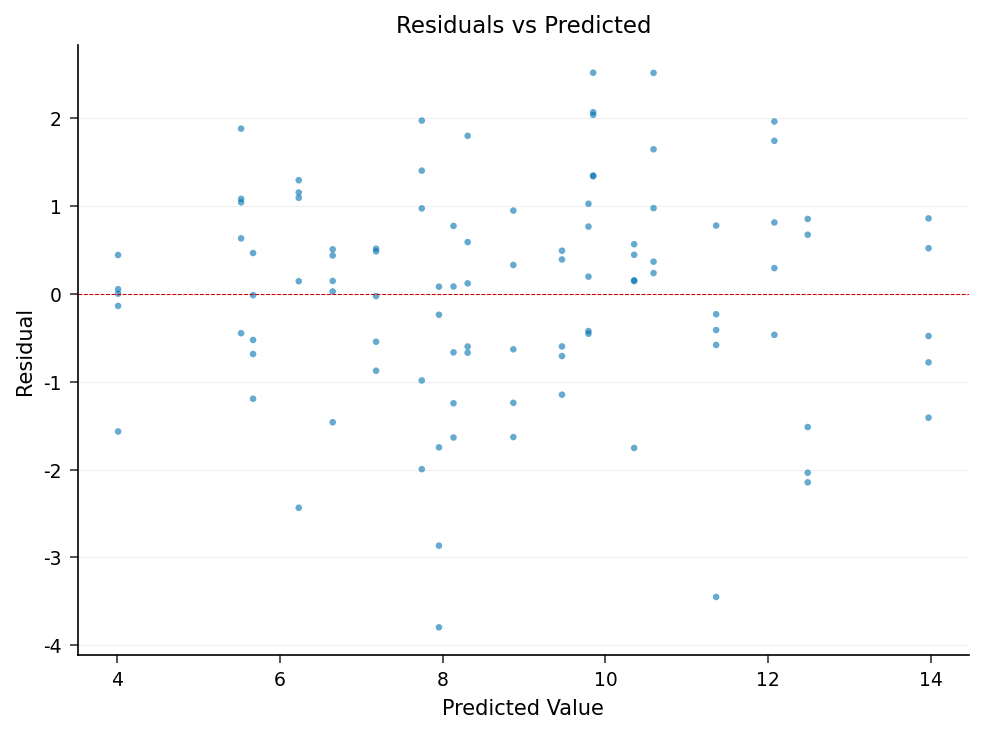

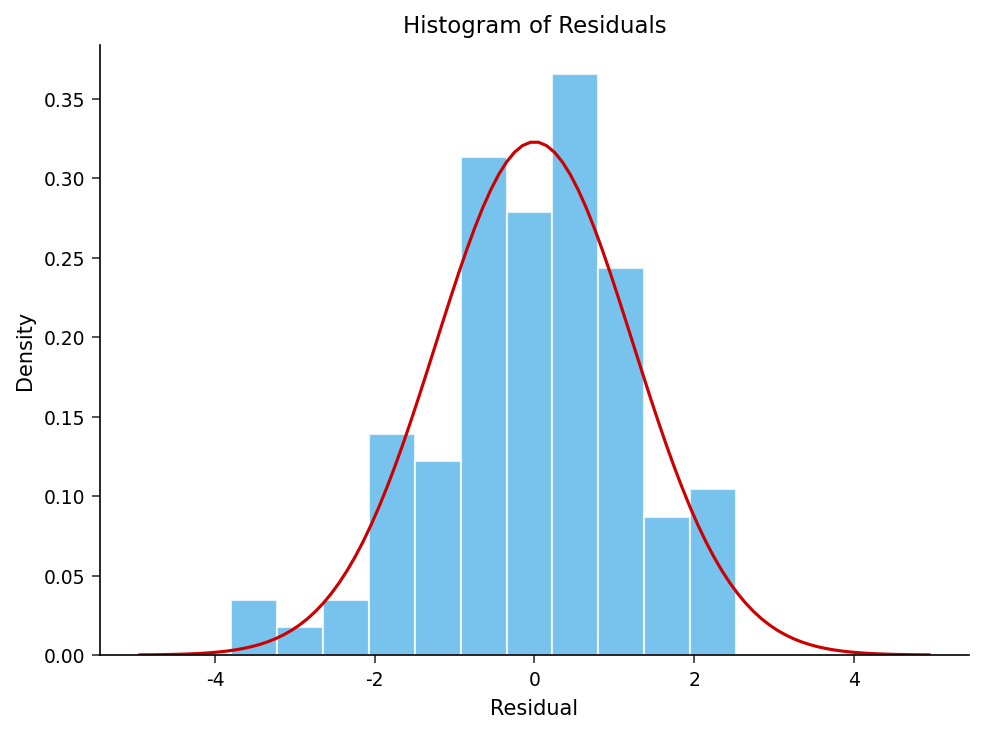

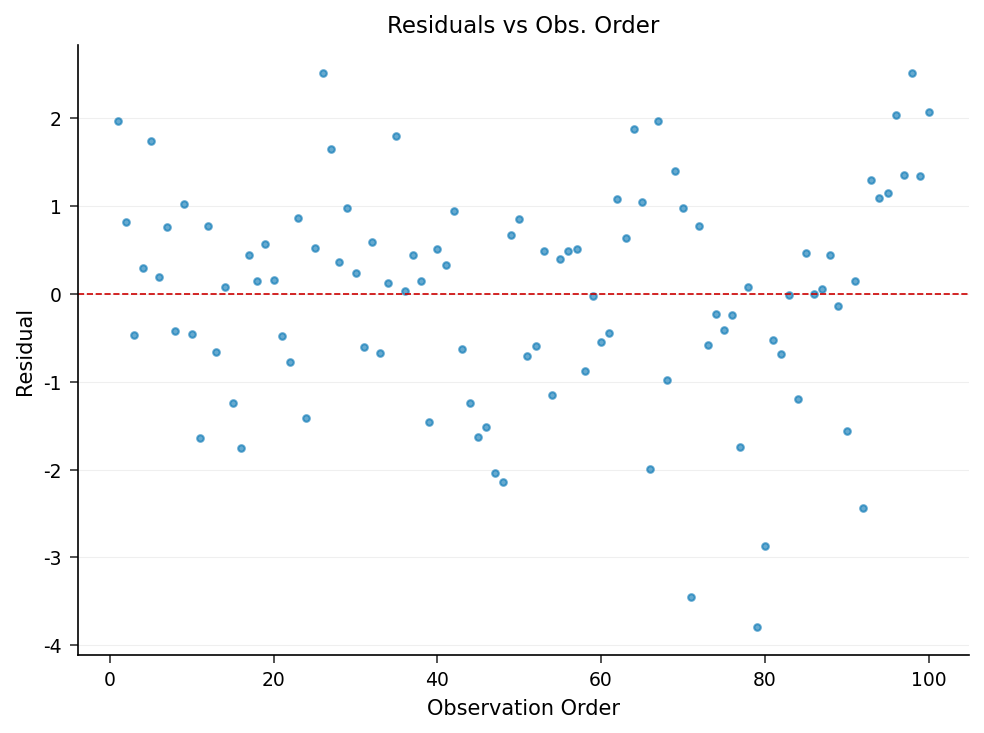

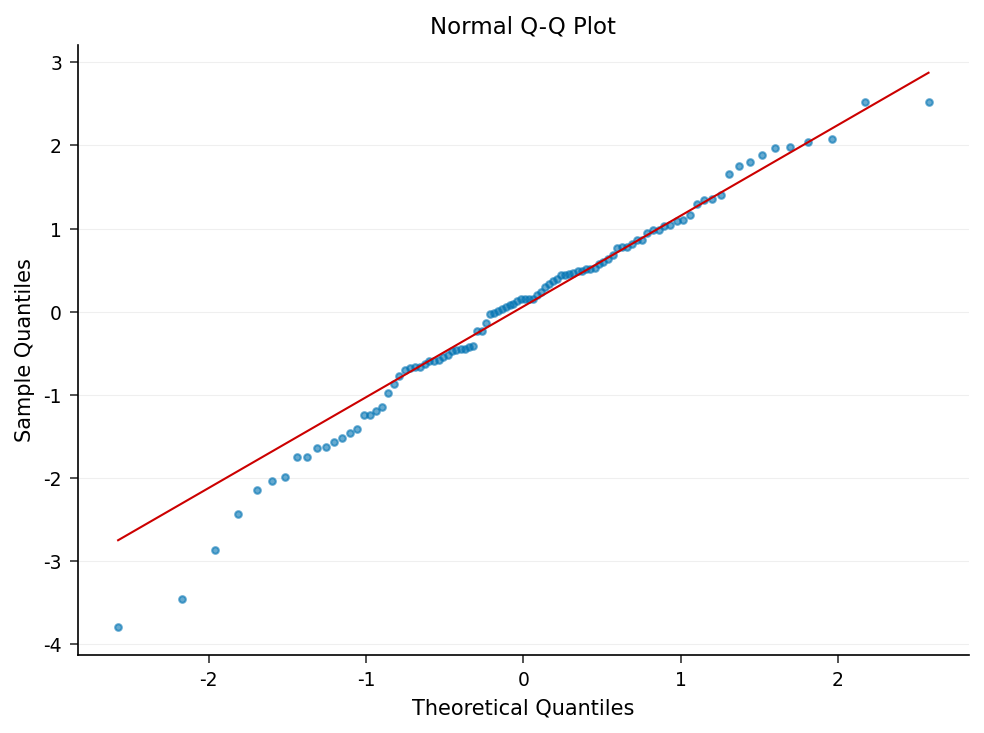

In [4]:
/* --------------------------------------------------------
   Analyse du modele mixte en parcelles divisees
   Machine est aleatoire (erreur de grande parcelle)
   Vitesse est fixe (facteur de sous-parcelle)
   -------------------------------------------------------- */
PROC MIXED data=work.molding_experiment METHOD=reml;
    CLASSE machine speed_label;
    MODÈLE defect_rate = speed_label / SOLUTION ddfm=kr;
    ALÉATOIRE machine;
    LSMEANS speed_label / ADJUST=TUKEY DIFF cl;
    ÉTIQUETTE machine="Machine"
          speed_label="Vitesse"
          defect_rate="Taux de défauts (%)";
    ODS OUTPUT LSMEANS=work.speed_lsmeans
              diffs=work.speed_diffs
              covparms=work.split_covparms
              fitstatistics=work.split_fit
              solutionf=work.split_fixed;
    TITRE "Analyse en parcelles divisées : effet de la vitesse sur le taux de défauts";
EXÉCUTER;

In [5]:
/* --------------------------------------------------------
   Identifier le reglage de vitesse optimal
   -------------------------------------------------------- */
PROC SORT data=work.speed_lsmeans;
    PAR estimate;
EXÉCUTER;

DONNÉES work.optimal_speed;
    DÉFINIR work.speed_lsmeans(obs=1);
    GARDER speed_label estimate stderr lower upper;
    ÉTIQUETTE speed_label = "Vitesse optimale"
          estimate = "Taux de défauts moyen (MMC)"
          lower = "IC 95% - borne inférieure"
          upper = "IC 95% - borne supérieure";
EXÉCUTER;

PROC PRINT data=work.optimal_speed noobs ÉTIQUETTE;
    TITRE "Vitesse de fonctionnement recommandée pour un taux de défauts minimal";
EXÉCUTER;

                         Vitesse de fonctionnement recommandée pour un taux de défauts minimal                          

Vitesse optimale   Taux de défauts moyen (MMC)  StdErr   IC 95% - borne inférieure   IC 95% - borne supérieure
               .                         6.081  0.9266                      3.3645                      8.7975




NOTE: PROC SORT data=work.speed_lsmeans

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from work.speed_lsmeans.
NOTE: Wrote work.speed_lsmeans (5 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.optimal_speed


NOTE: Read 1 rows from work.speed_lsmeans.
NOTE: Wrote work.optimal_speed (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.optimal_speed

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


In [6]:
/* --------------------------------------------------------
   Decomposition des composantes de variance
   -------------------------------------------------------- */
PROC PRINT data=work.split_covparms noobs;
    TITRE "Composantes de variance : machine vs résiduelle";
EXÉCUTER;

                                    Composantes de variance : machine vs résiduelle                                     

  COVPARM  ESTIMATE
Intercept    3.1033
Residual     1.6566




NOTE: PROC PRINT data=work.split_covparms

NOTE: PROC PRINT completed: 2 observations printed, 2 variables


---

### Interprétation

Le modèle en parcelles divisées répartit la variabilité du taux de défauts en deux strates. La **composante de variance machine (grande parcelle) est de 3,10** et la **variance résiduelle (sous-parcelle) est de 1,66**, si bien que les différences entre machines représentent environ **65 %** de la variance totale (3,10 / (3,10 + 1,66)). Cette large part inter-machines confirme que la machine est une véritable source de variation du procédé et que le plan en parcelles divisées - plutôt qu'une analyse entièrement randomisée - est le cadre correct.

Le test de type III de l'effet fixe vitesse est hautement significatif : **F(4, 92) = 60,26, p < 0,0001**, donc le réglage en tr/min affecte fortement le taux de défauts. Les moyennes des moindres carrés dessinent une réponse quadratique claire avec un minimum à la vitesse intermédiaire :

| Vitesse | Taux de défauts moyen (MMC, %) | IC à 95 % |
|-------|------------------------|--------|
| **100 tr/min** | **6,08** | 3,36 - 8,80 |
| 80 tr/min | 7,74 | 5,02 - 10,46 |
| 120 tr/min | 8,30 | 5,58 - 11,02 |
| 60 tr/min | 10,02 | 7,31 - 12,74 |
| 140 tr/min | 11,92 | 9,20 - 14,63 |

Les comparaisons deux à deux ajustées par Tukey montrent que **100 tr/min est significativement inférieur à tous les autres réglages** (p ajusté <= 0,0009 contre 80, 120, 60 et 140 tr/min). Les réglages 80 tr/min et 120 tr/min se situent au milieu et ne diffèrent **pas** l'un de l'autre (différence 0,56, p ajusté = 0,6430), tandis que 60 tr/min et 140 tr/min produisent les taux de défauts les plus élevés.

**Recommandation d'ingénierie :** standardiser la production à **100 tr/min** sur les quatre machines, là où le modèle estime le taux de défauts le plus bas (6,08 %). Comme la composante de variance machine (3,10) est la principale source de variabilité, les travaux de suivi devraient cibler un calibrage spécifique à chaque machine - le profil d'interaction montre que MACH_D est systématiquement la plus basse et MACH_A la plus haute - afin de réduire l'écart entre machines au point de consigne choisi de 100 tr/min.

---

In [7]:
/* --------------------------------------------------------
   Exporter les resultats d'optimisation de vitesse pour l'ingenierie
   -------------------------------------------------------- */
PROC EXPORT data=work.speed_lsmeans
    OUTFILE='speed_optimization_lsmeans.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;

PROC EXPORT data=work.split_covparms
    OUTFILE='variance_components.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;


NOTE: PROC EXPORT data=work.speed_lsmeans outfile=speed_optimization_lsmeans.csv

NOTE: Exported 5 rows to speed_optimization_lsmeans.csv.
NOTE: PROC EXPORT data=work.split_covparms outfile=variance_components.csv

NOTE: Exported 2 rows to variance_components.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidentiel
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Optimisé par <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>